In [1]:
library(forecast)
library(tseries)
library(ggplot2)
library(zoo)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




In [2]:
# Leitura e conversão para ts
dados <- read.csv("strikes.csv")
dados <- dados[order(dados$ds), ]

ano_inicio <- as.integer(format(as.Date(dados$ds[1]), "%Y"))

ts_data <- ts(dados$y, start = ano_inicio, frequency = 1)

cat("Classe    :", class(ts_data), "\n")
cat("Início    :", start(ts_data), "\n")
cat("Fim       :", end(ts_data), "\n")
cat("Frequência:", frequency(ts_data), "(anual)\n")
cat("N obs     :", length(ts_data), "\n")
print(summary(ts_data))

Classe    : ts 
Início    : 1951 1 
Fim       : 1980 1 
Frequência: 1 (anual)
N obs     : 30 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3333    3698    4500    4503    5110    6074 


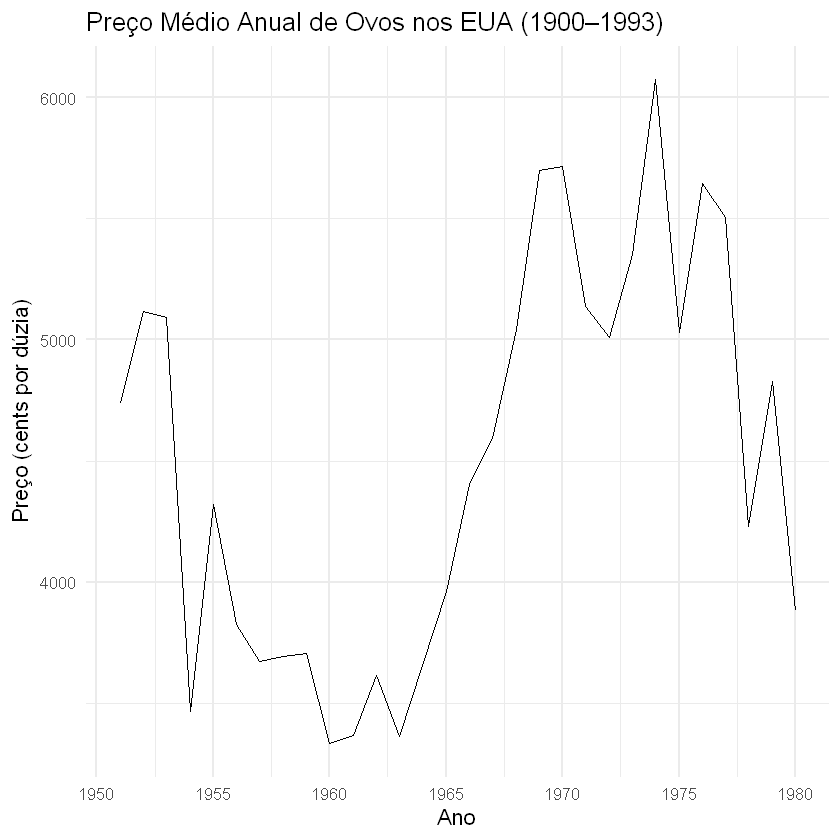

In [3]:
autoplot(ts_data) +
  labs(
    title = "Preço Médio Anual de Ovos nos EUA (1900–1993)",
    x     = "Ano",
    y     = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`)."


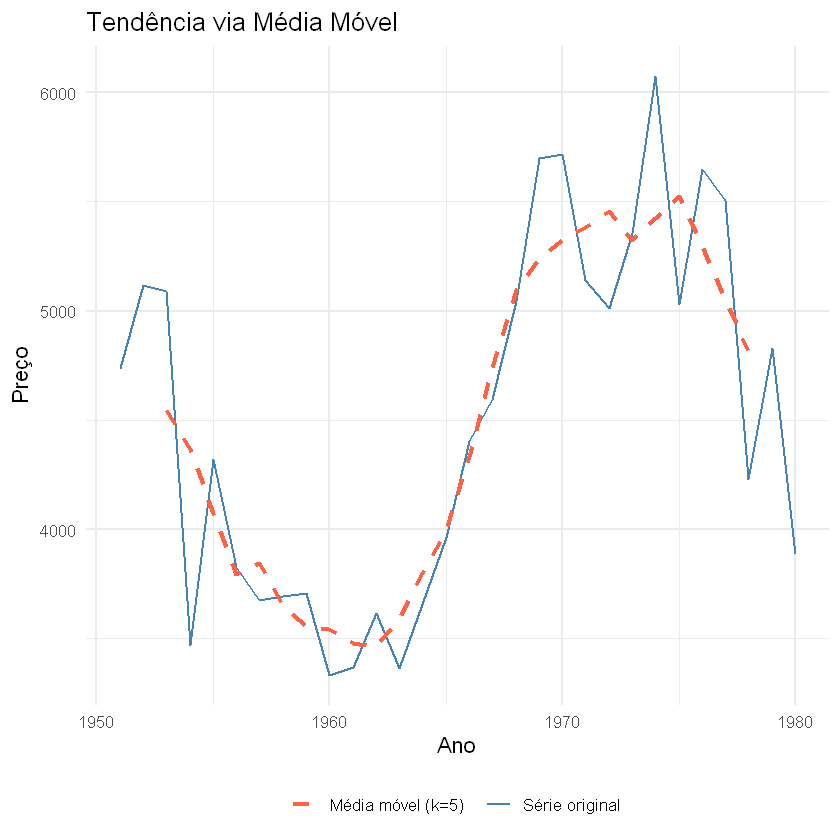

In [4]:
# Média móvel de ordem 5 para suavizar a tendência
library(zoo)
tendencia <- rollmean(ts_data, k = 5, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_data)),
  original  = as.numeric(ts_data),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "steelblue", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

In [5]:
cat("=== Teste ADF — Série Original ===\n")
print(adf.test(ts_data))

=== Teste ADF — Série Original ===

	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -1.1305, Lag order = 3, p-value = 0.9026
alternative hypothesis: stationary



Diferenças aplicadas: 1 


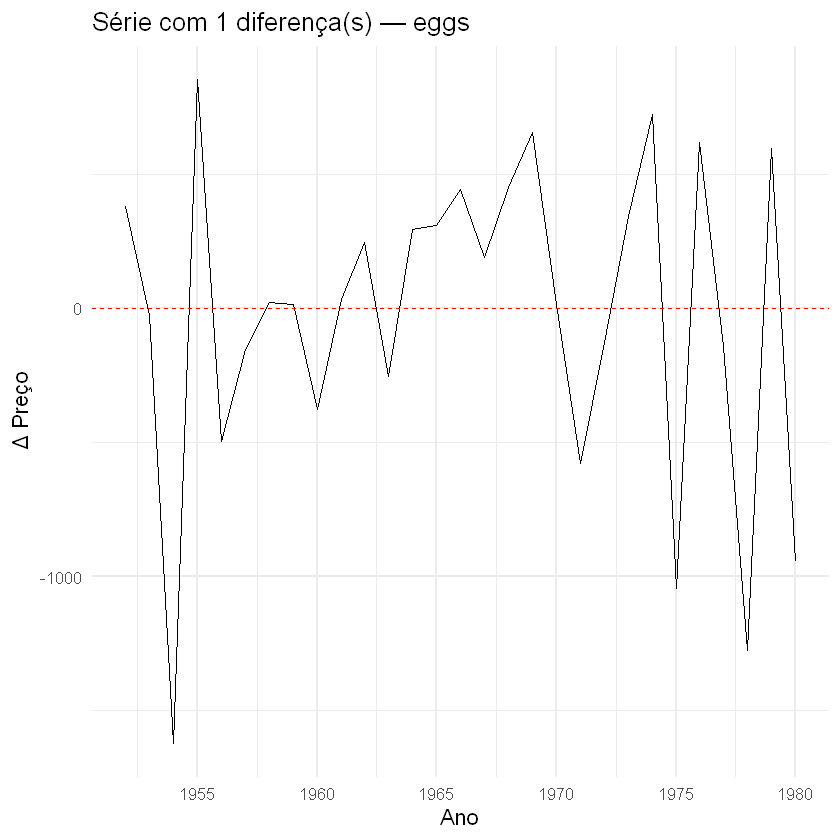

In [6]:
# Aplicando diferenciação simples
d <- ndiffs(ts_data)   # número de diferenças indicado

ts_diff <- ts_data
for (i in seq_len(d)) ts_diff <- diff(ts_diff)

cat("Diferenças aplicadas:", d, "\n")

autoplot(ts_diff) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = paste0("Série com ", d, " diferença(s) — eggs"),
    x = "Ano", y = "Δ Preço"
  ) +
  theme_minimal(base_size = 13)

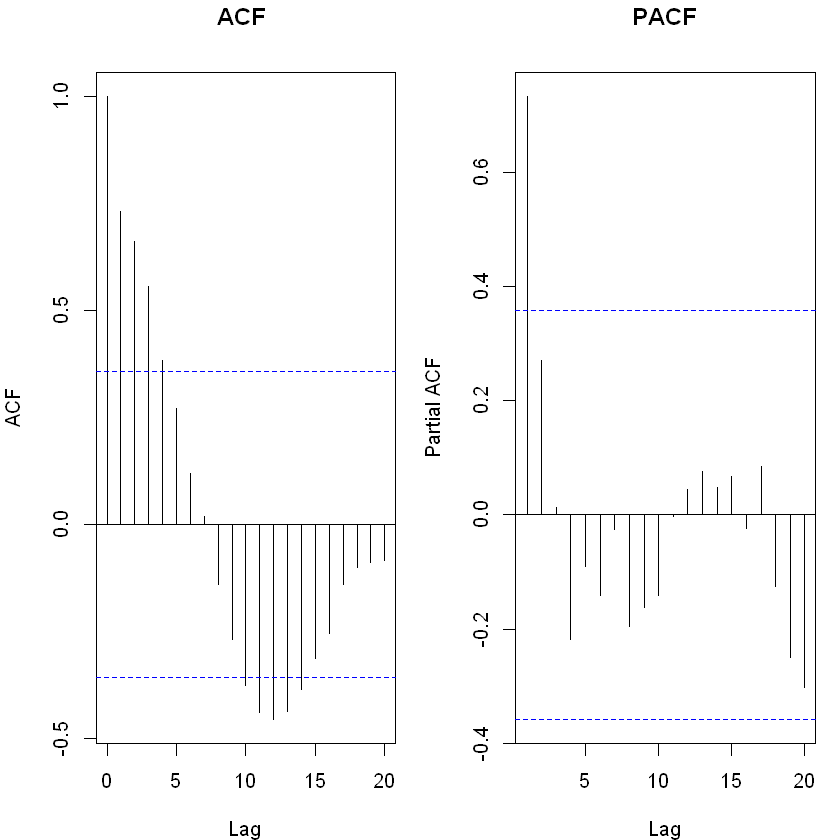

In [7]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(ts_data,  lag.max = 20, main = "ACF ")
pacf(ts_data, lag.max = 20, main = "PACF")

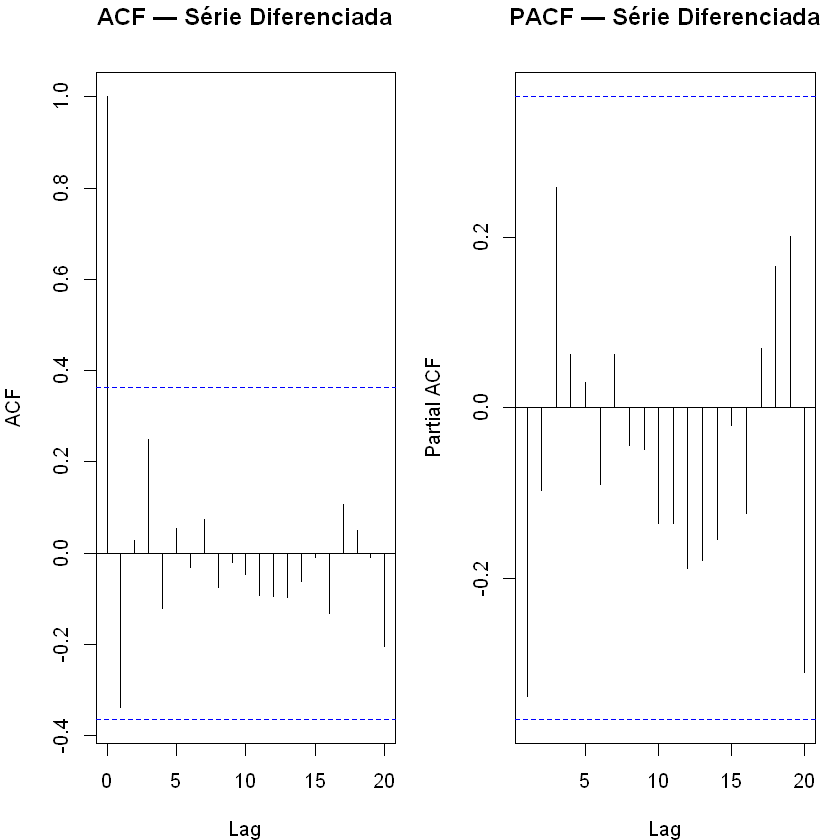

In [8]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(ts_diff,  lag.max = 20, main = "ACF — Série Diferenciada")
pacf(ts_diff, lag.max = 20, main = "PACF — Série Diferenciada")